# ***Exploratory Data Analysis for Bronze Layer***

In [12]:
import os
from dotenv import load_dotenv
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Load environment variables from .env file
load_dotenv()

# Set the path to the JDBC driver JAR file
JDBC_JAR_PATH = r"C:\Users\91852\OneDrive\Desktop\Museum\drivers\postgresql.jar"

# Create a SparkSession
spark = (
    SparkSession.builder
    .appName("MuseumEDA")
    .master("local[*]")
    .config("spark.driver.extraClassPath", JDBC_JAR_PATH)
    .config("spark.executor.extraClassPath", JDBC_JAR_PATH)
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

JDBC_URL = f"jdbc:postgresql://{os.getenv('POSTGRES_HOST', 'localhost')}:{os.getenv('POSTGRES_PORT', '5432')}/{os.getenv('POSTGRES_DATABASE', 'Museum')}"
DB_USER = os.getenv('POSTGRES_USERNAME')
DB_PASS = os.getenv('POSTGRES_PASSWORD')

# Helper function to read a table from PostgreSQL into a Spark DataFrame
def load_table(table_name):
    return (
        spark.read
        .format("jdbc")
        .option("url", JDBC_URL)
        .option("dbtable", f'"bronze"."{table_name}"')
        .option("user", DB_USER)
        .option("password", DB_PASS)
        .option("driver", "org.postgresql.Driver")
        .load()
    )

print("PySpark initialized and ready to query Postgres!")



PySpark initialized and ready to query Postgres!


In [13]:
# Bronze tables check
schema_query = """
    (SELECT table_name, COUNT(column_name) as number_of_columns
        FROM information_schema.columns
        WHERE table_schema = 'bronze'
        GROUP BY table_name
        ORDER BY table_name) AS schema_metadata
"""
# Load the schema metadata into a Spark DataFrame
schema_df = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("dbtable", schema_query)
    .option("user", DB_USER)
    .option("password", DB_PASS)
    .option("driver", "org.postgresql.Driver")
    .load()
).toPandas()

print("Calculating exact row counts... (this will take a few seconds)")
row_counts = []
for table in schema_df['table_name']:
    exact_count = load_table(table).count()
    row_counts.append(exact_count)

schema_df['number_of_rows'] = row_counts
schema_df = schema_df.sort_values(by='number_of_rows', ascending=False).reset_index(drop=True)

schema_df["number_of_rows"] = schema_df["number_of_rows"].apply(lambda x: f"{x:,}")

print("Bronze Schema Overview:")
display(schema_df)

Calculating exact row counts... (this will take a few seconds)
Bronze Schema Overview:


,table_name,number_of_columns,number_of_rows
0,product_size,8,"219,320"
1,subject,6,"20,195"
2,work,8,"14,716"
3,museum_hours,8,700
4,artist,12,421
5,canvas_size,7,200
6,museum,12,57


In [14]:
def profile_table(table_name):
    df = load_table(table_name)
    total_rows = df.count()

    print(f"Profiling Table: '{table_name}' ({total_rows:,} rows)")
    print("-" * 50)

    if total_rows == 0:
        print("This table is empty. Skipping profiling.")
        return
    
    # 1. Get data types
    # df.dtypes returns a list of tuples: [('column_name', 'data_type'), ...]
    dtypes_df = pd.DataFrame(df.dtypes, columns=["Column", "DataType"])

    # 2. Get null counts
    # spark go through each column and count nulls
    null_exprs = [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns]
    null_counts_df = df.select(*null_exprs).toPandas().T.reset_index()
    null_counts_df.columns = ["Column", "NullCount"]

    # 3. Combine data types and null counts
    # Merge the two DataFrames on the 'Column' column
    profile_df = pd.merge(dtypes_df, null_counts_df, on="Column")

    # Calculate the percentage of missing data
    profile_df["Missing%"] = (profile_df["NullCount"] / total_rows * 100).round(2)
    profile_df["Missing%"] = profile_df["Missing%"].astype(str) + "%"

    # Sort by the most missing data first
    profile_df = profile_df.sort_values(by="NullCount", ascending=False).reset_index(drop=True)
    
    display(profile_df)

profile_table("product_size")

Profiling Table: 'product_size' (219,320 rows)
--------------------------------------------------


,Column,DataType,NullCount,Missing%
0,updated_at,string,109660,50.0%
1,_etl_id,int,0,0.0%
2,size_id,string,0,0.0%
3,work_id,string,0,0.0%
4,sale_price,string,0,0.0%
5,regular_price,string,0,0.0%
6,loaded_at,string,0,0.0%
7,_row_hash,string,0,0.0%


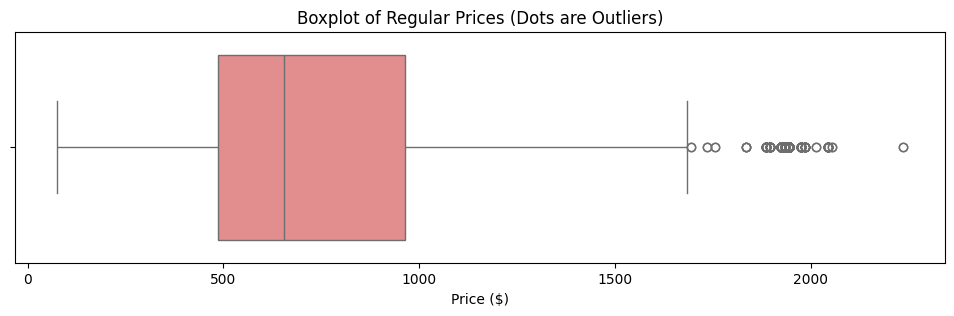

In [15]:
# 1. Load the raw data
df_prices_raw = load_table("product_size")

# 2. Clean and cast the prices to numbers in Spark
clean_prices_spark = (
    df_prices_raw
    .filter(
        (F.col("regular_price").isNotNull()) & 
        (F.col("regular_price") != "nan") & 
        (F.col("regular_price") != "")
    )
    .withColumn("price", F.col("regular_price").cast("double"))
    .select("work_id", "price")
)

# 3. Bring the single column into Pandas for plotting
pdf_prices = clean_prices_spark.select("price").toPandas()

# 4. Draw the Boxplot
plt.figure(figsize=(12, 3))
sns.boxplot(x=pdf_prices['price'], color='lightcoral')
plt.title("Boxplot of Regular Prices (Dots are Outliers)")
plt.xlabel("Price ($)")
plt.show()

In [16]:
# Stop the Spark session and release resources
spark.stop()

print("Spark session successfully closed!")

Spark session successfully closed!
